<a href="https://colab.research.google.com/github/MarrissaSyokwaa/datascienceprojects/blob/main/TENSOR_FLOW_SKLEARN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

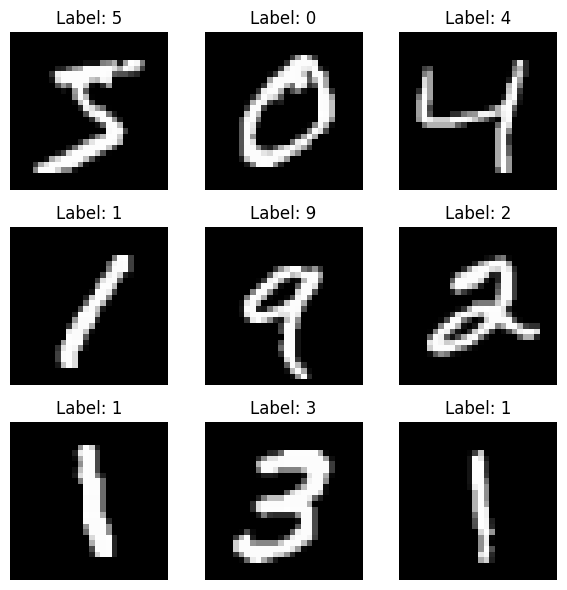

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Visualize 9 random images
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.utils import to_categorical

# Normalize pixels
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Train Shape: {X_train.shape}, Labels Shape: {y_train_cat.shape}")

Train Shape: (60000, 28, 28), Labels Shape: (60000, 10)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    Flatten(input_shape=(28, 28)),          # Input Layer
    Dense(128, activation='relu'),         # Hidden Layer 1
    Dropout(0.3),                          # Regularization
    Dense(64, activation='relu'),          # Hidden Layer 2
    Dropout(0.3),                          # Regularization
    Dense(10, activation='softmax')        # Output Layer (10 classes)
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8314 - loss: 0.5512 - val_accuracy: 0.9507 - val_loss: 0.1620
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9253 - loss: 0.2577 - val_accuracy: 0.9647 - val_loss: 0.1147
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9406 - loss: 0.1993 - val_accuracy: 0.9727 - val_loss: 0.0936
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9516 - loss: 0.1663 - val_accuracy: 0.9737 - val_loss: 0.0872
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9572 - loss: 0.1477 - val_accuracy: 0.9753 - val_loss: 0.0856
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9610 - loss: 0.1339 - val_accuracy: 0.9777 - val_loss: 0.0729
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9644 - loss: 0.1198 - val_accuracy: 0.9783 - val_loss: 0.0730
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9668 - loss: 0.1117 - val_accuracy: 0

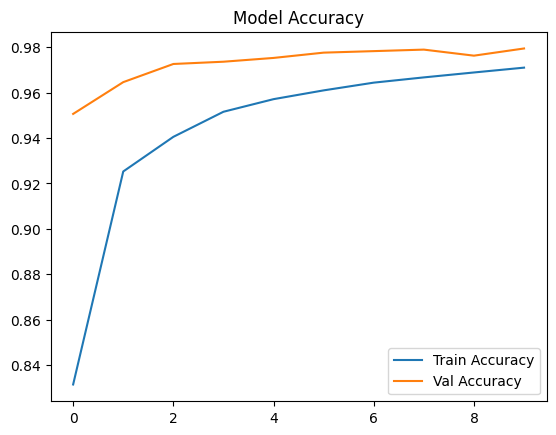

In [ ]:
history = model.fit(X_train, y_train_cat, epochs=10, batch_size=128, validation_split=0.1)

# Plotting Results
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


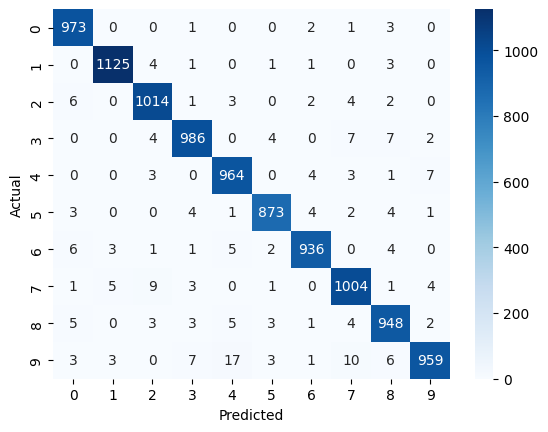

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9782 - loss: 0.0755
Final Test Accuracy: 0.9782


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Final Accuracy
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print(f"Final Test Accuracy: {test_acc:.4f}")

# Save the model
model.save('mnist_ann_model.keras')